In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
file_path = 'Jan 1st week Spare Parts PO.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

In [4]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (1629, 102)

First 5 rows:


,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Address Blocked (Sold-To),Requirement Segment,Address Blocked (Partner),Employee ID,Action Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity
0,Dec Loss orders,2025-01-07,ZP1A,40032306,10,27190,571901NAE,20,EA,33686.40,...,NaN,NaN,NaN,NaN,NaN,ZABP,20,0,Manohar Shankavi,0
1,Dec Loss orders,2025-01-07,ZP1A,40032306,10,27190,571901NAE,20,EA,33686.40,...,NaN,NaN,NaN,NaN,NaN,ZABP,20,0,Manohar Shankavi,0
2,Dec Loss orders,2025-01-07,ZP1A,40032306,20,27190,571902NAE,20,EA,33686.40,...,NaN,NaN,NaN,NaN,NaN,ZABP,20,20,Manohar Shankavi,0
3,Dec Loss orders,2025-01-07,ZP2A,40032305,10,18410,94701-00254,650,EA,220962.09,...,NaN,NaN,NaN,NaN,NaN,ZABP,650,650,Manohar Shankavi,0
4,Dec Loss orders,2025-01-07,ZP1A,40032304,10,74217,2FS-E2170-10-00,2,EA,14250.00,...,NaN,NaN,NaN,NaN,NaN,ZABP,2,0,Manohar Shankavi,0


In [5]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Customer Reference', 'Document Date', 'Sales Document Type', 'Sales Document', 'Sales Document Item', 'Sold-to Party', 'Material', 'Order Quantity (Item)', 'Sales Unit', 'Net Value (Item)', 'Document Currency', 'Order Reason', 'Customer Reference (Header)', 'Created By', 'Created On', 'Time', 'Billing Block', 'Sales Document Description', 'Exchange Rate Type', 'Delivery Block', 'Net Value (Header)', 'Division', 'SD Document Category', 'Sales Office', 'Sales Group', 'Sales Organization', 'Distribution Channel', 'Overall Status', 'Overall Delivery Status (All Items)', 'Sold-To Party Name', 'Reason for Rejection', 'Material Description', 'Batch', 'Confirmed Quantity (Item)', 'Pricing Unit', 'Pricing Unit (per)', 'Storage Location', 'Base Unit of Measure', 'Net Price', 'Returns', 'Shipping Point/Receiving Pt', 'Plant', 'Target Quantity', 'Overall Status Item', 'Overall Delivery Status (Item)', 'Exchange Rate', 'Pricing Date', 'Personnel Partner Function', 'Personnel Number

In [6]:
print("\nData types and non‑null counts:")
df.info()


Data types and non‑null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Columns: 102 entries, Customer Reference to AF Open Order Quantity
dtypes: datetime64[ns](6), float64(42), int64(19), object(35)
memory usage: 1.3+ MB


In [7]:
# Convert date columns to datetime
date_cols = ['Document Date', 'Created On', 'Delivery Date', 'Goods Issue Date',
             'Material Availability Date', 'Contract Start Date', 'Contract End Date',
             'Req.Cancellat.Date', 'Date of Canc.Doc.', 'Dismantling Date', 'Action Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [8]:
# Convert numeric columns (force errors to NaN)
num_cols = ['Order Quantity (Item)', 'Net Value (Item)', 'Confirmed Quantity (Item)',
            'Net Value (Header)', 'Confirmed Quantity (Schedule Line)',
            'Order Quantity (Schedule Line)', 'Rounded Quantity (Schedule Line)',
            'AF Open Confirmed quantity', 'AF Open Order Quantity']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
# Create a unit price column (Net Value per quantity)
df['Unit Price'] = df['Net Value (Item)'] / df['Order Quantity (Item)']

# Extract date parts
df['Document YearMonth'] = df['Document Date'].dt.to_period('M')
df['Document Week'] = df['Document Date'].dt.isocalendar().week
df['Document Day'] = df['Document Date'].dt.date

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Columns with missing values:")
missing_df

Columns with missing values:


,Missing Count,Percentage
Billing Block,1629,100.000000
Sales Document Description,1629,100.000000
Exchange Rate Type,1629,100.000000
Delivery Block,1629,100.000000
Batch,1629,100.000000
Personnel Partner Function,1629,100.000000
Returns,1629,100.000000
Partner Function,1629,100.000000
Personnel Number,1629,100.000000
Req.Cancellat.Date,1629,100.000000


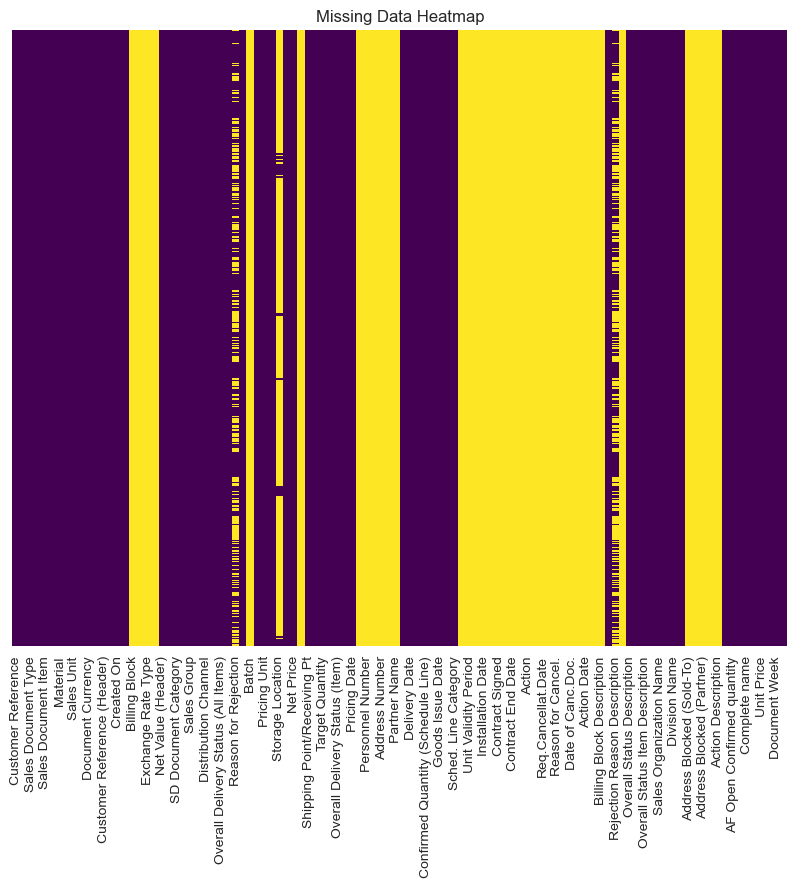

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [12]:
df.describe()

,Document Date,Sales Document,Sales Document Item,Sold-to Party,Order Quantity (Item),Net Value (Item),Created On,Billing Block,Sales Document Description,Exchange Rate Type,...,Address Blocked (Sold-To),Requirement Segment,Address Blocked (Partner),Employee ID,Action Description,AF Open Confirmed quantity,Af Open Confirmed Value,AF Open Order Quantity,Unit Price,Document Week
count,1629,1.629000e+03,1629.000000,1629.000000,1629.000000,1629.000000,1629,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1629.000000,1629.000000,1629.000000,1629.000000,1629.0
mean,2025-01-06 13:59:46.740331264,4.003192e+07,273.333333,44006.481891,10.928791,11064.510546,2025-01-06 13:59:46.740331264,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,10.928791,5.256599,0.295887,1920.108411,1.963168
min,2025-01-01 00:00:00,4.003146e+07,10.000000,10862.000000,1.000000,29.080000,2025-01-01 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,10.125000,1.0
25%,2025-01-06 00:00:00,4.003177e+07,60.000000,17111.000000,2.000000,2084.740000,2025-01-06 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2.000000,0.000000,0.000000,375.000000,2.0
50%,2025-01-07 00:00:00,4.003199e+07,160.000000,35326.000000,5.000000,4932.180000,2025-01-07 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5.000000,0.000000,0.000000,902.542000,2.0
75%,2025-01-07 00:00:00,4.003216e+07,390.000000,73064.000000,10.000000,11949.150000,2025-01-07 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,10.000000,5.000000,0.000000,1805.083333,2.0
max,2025-01-07 00:00:00,4.003231e+07,1440.000000,126611.000000,650.000000,220962.090000,2025-01-07 00:00:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,650.000000,650.000000,60.000000,44752.120000,2.0
std,NaN,2.927222e+02,292.465584,29989.772730,30.094749,21422.880228,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,30.094749,25.441178,2.726855,3275.995892,0.188408


In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols[:5]:  # show first 5 categorical columns
    print(f"\nTop 10 values in {col}:")
    print(df[col].value_counts().head(10))


Top 10 values in Customer Reference:
Customer Reference
Dec Loss orders    563
po no 3804         148
po no 3802         101
2349 (Gayan)        66
Dec Loss Orders     64
2345 (Gayan)        60
po no 3807          55
DR00004306          34
2347 (Gayan)        33
PO 2611 NEW         31
Name: count, dtype: int64

Top 10 values in Sales Document Type:
Sales Document Type
ZP1A    1513
ZP2A     116
Name: count, dtype: int64

Top 10 values in Material:
Material
1GC-E7641-10-00    24
1GC-E4450-00-00    21
B62-H3550-10       20
1GC-E7632-01       17
2FS-F6311-00-00    17
1GC-F5138-10-00    16
1GC-E7620-00-00    15
1GC-E7611-00-00    15
2GS-E4450-00-00    14
93822-14800        14
Name: count, dtype: int64

Top 10 values in Sales Unit:
Sales Unit
EA    1629
Name: count, dtype: int64

Top 10 values in Document Currency:
Document Currency
LKR    1629
Name: count, dtype: int64


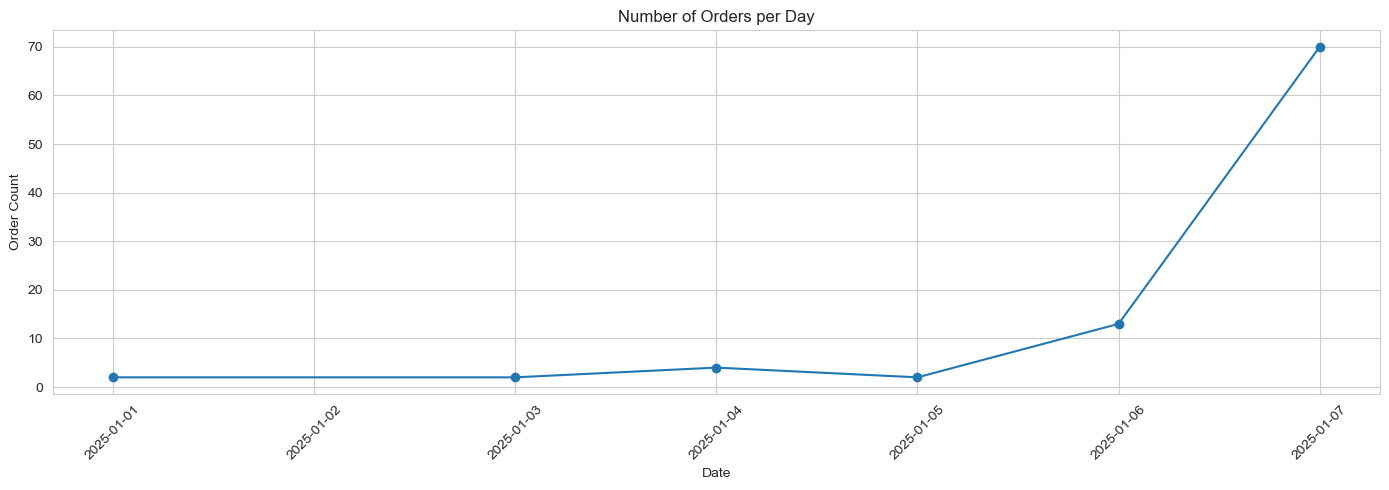

In [14]:
# Orders per day
daily_orders = df.groupby('Document Day')['Sales Document'].nunique().reset_index()
daily_orders.columns = ['Date', 'Number of Orders']

plt.figure(figsize=(14, 5))
plt.plot(daily_orders['Date'], daily_orders['Number of Orders'], marker='o', linestyle='-')
plt.title('Number of Orders per Day')
plt.xlabel('Date')
plt.ylabel('Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

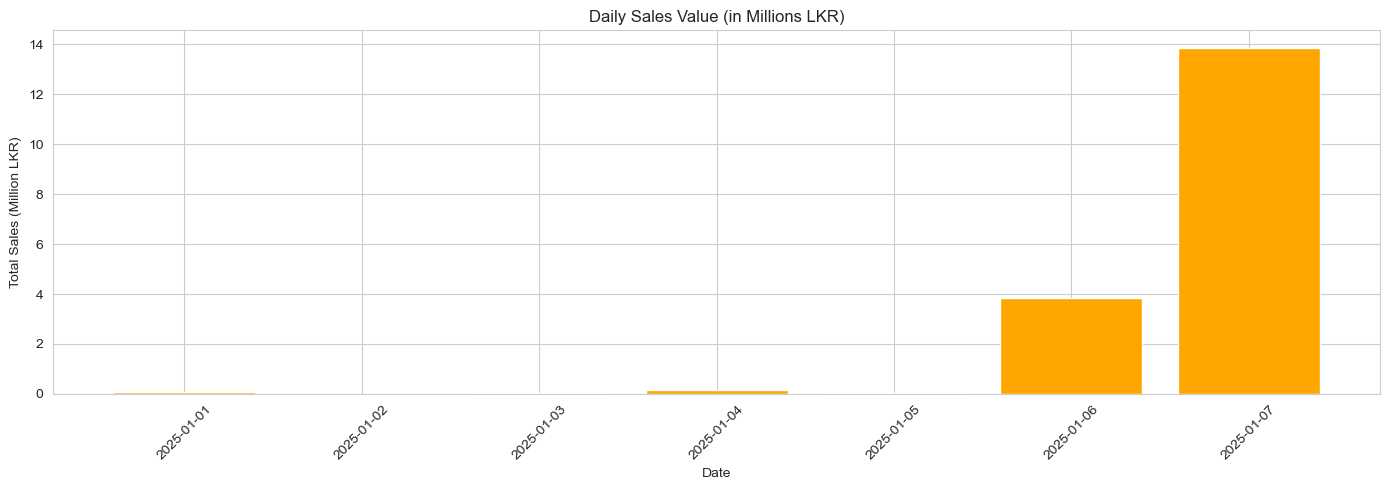

In [15]:
# Total value per day
daily_value = df.groupby('Document Day')['Net Value (Item)'].sum().reset_index()
daily_value.columns = ['Date', 'Total Sales (LKR)']

plt.figure(figsize=(14, 5))
plt.bar(daily_value['Date'], daily_value['Total Sales (LKR)']/1e6, color='orange')
plt.title('Daily Sales Value (in Millions LKR)')
plt.xlabel('Date')
plt.ylabel('Total Sales (Million LKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

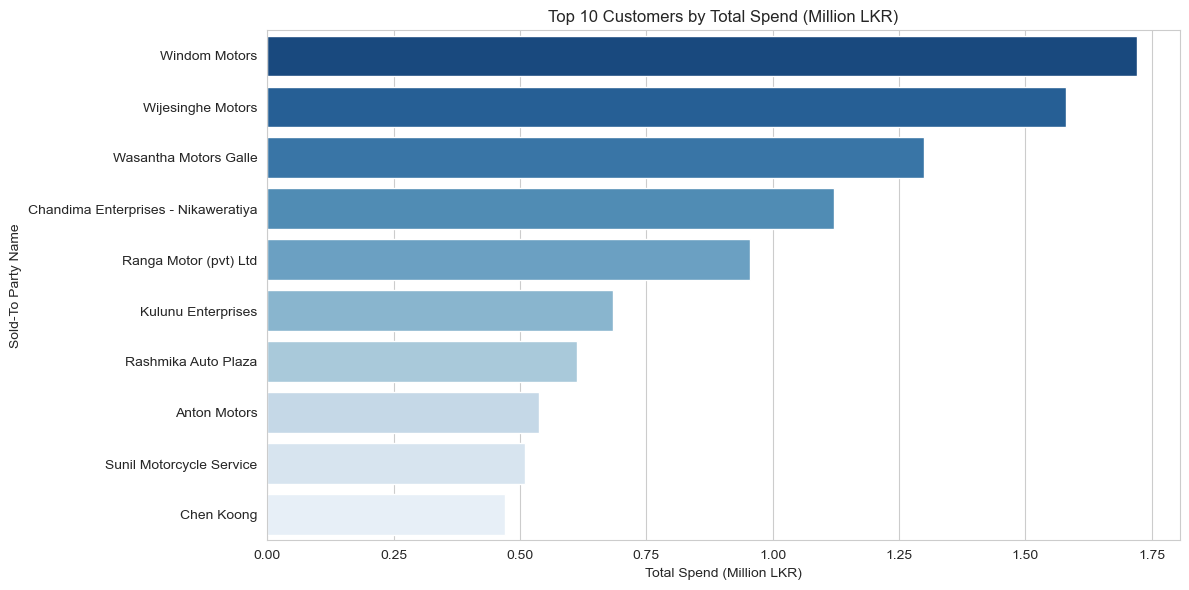

In [16]:
top_customers = df.groupby('Sold-To Party Name')['Net Value (Item)'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_customers.values/1e6, y=top_customers.index, palette='Blues_r')
plt.title('Top 10 Customers by Total Spend (Million LKR)')
plt.xlabel('Total Spend (Million LKR)')
plt.tight_layout()
plt.show()

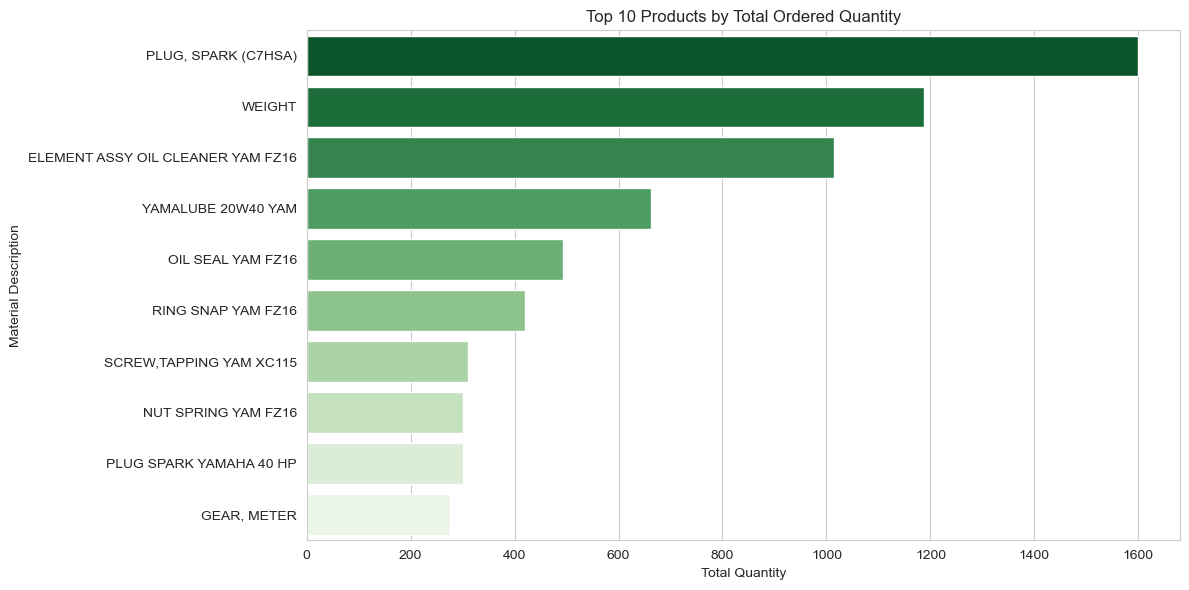

In [17]:
# Top 10 products by order quantity
top_products_qty = df.groupby('Material Description')['Order Quantity (Item)'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_qty.values, y=top_products_qty.index, palette='Greens_r')
plt.title('Top 10 Products by Total Ordered Quantity')
plt.xlabel('Total Quantity')
plt.tight_layout()
plt.show()

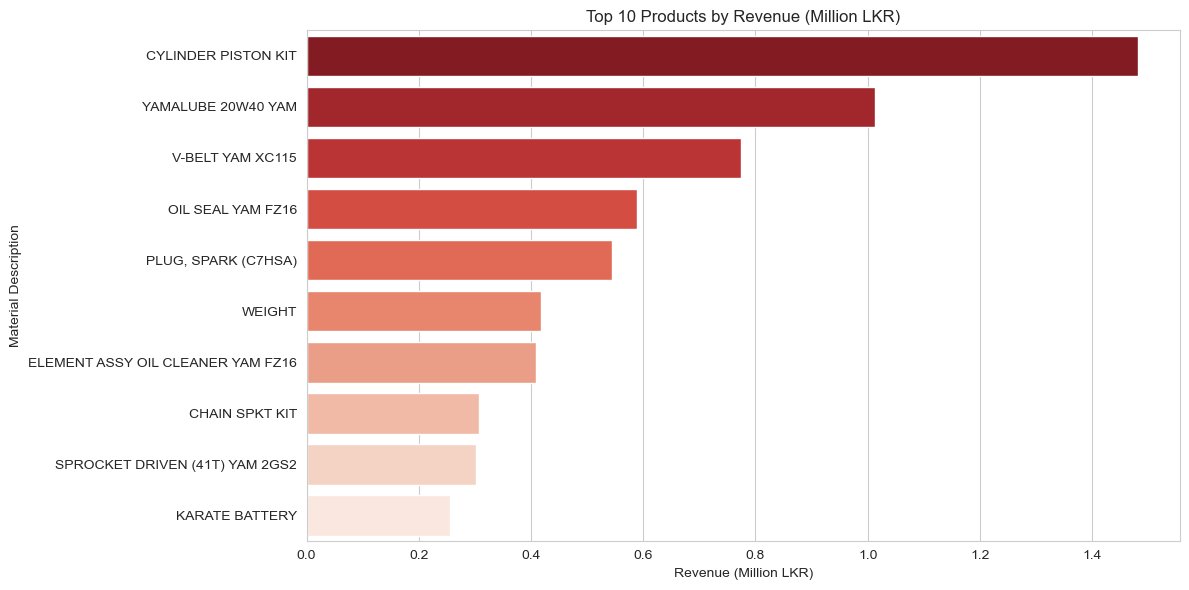

In [18]:
# Top 10 products by revenue
top_products_rev = df.groupby('Material Description')['Net Value (Item)'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_rev.values/1e6, y=top_products_rev.index, palette='Reds_r')
plt.title('Top 10 Products by Revenue (Million LKR)')
plt.xlabel('Revenue (Million LKR)')
plt.tight_layout()
plt.show()

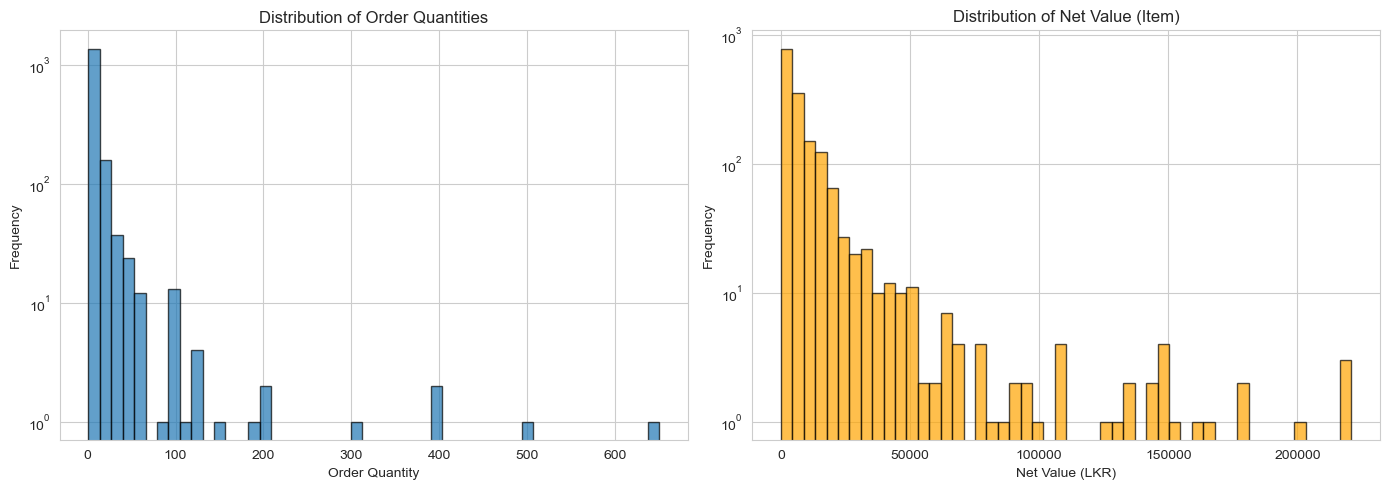

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Order quantity distribution (log scale due to wide range)
axes[0].hist(df['Order Quantity (Item)'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Order Quantity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Order Quantities')
axes[0].set_yscale('log')

# Net value distribution (log scale)
axes[1].hist(df['Net Value (Item)'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Net Value (LKR)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Net Value (Item)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

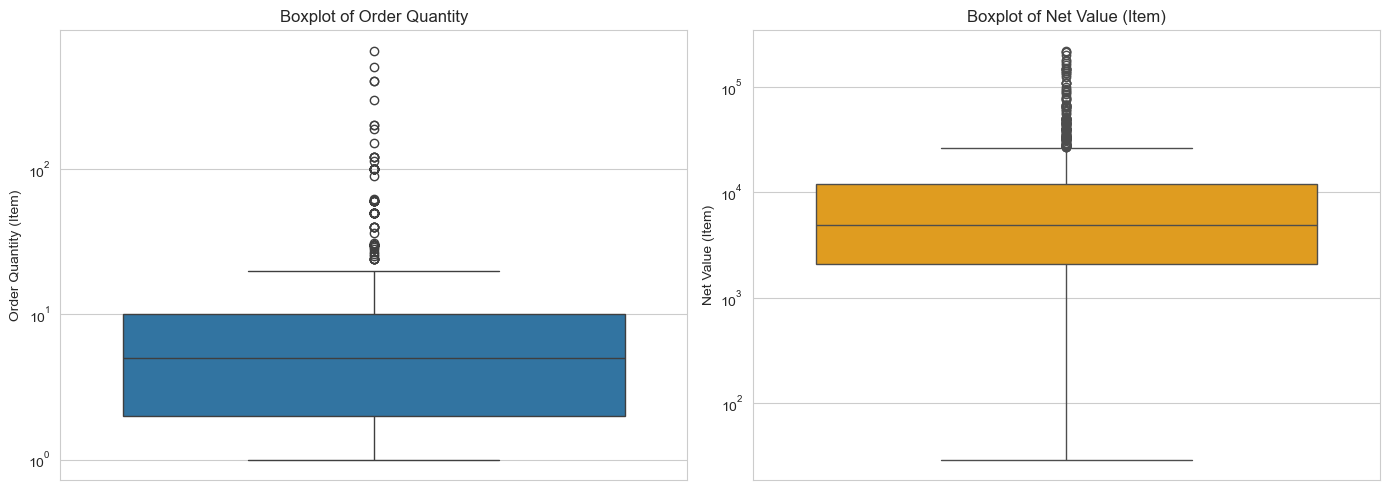

In [20]:
# Boxplots to detect outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['Order Quantity (Item)'], ax=axes[0])
axes[0].set_title('Boxplot of Order Quantity')
axes[0].set_yscale('log')

sns.boxplot(y=df['Net Value (Item)'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot of Net Value (Item)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

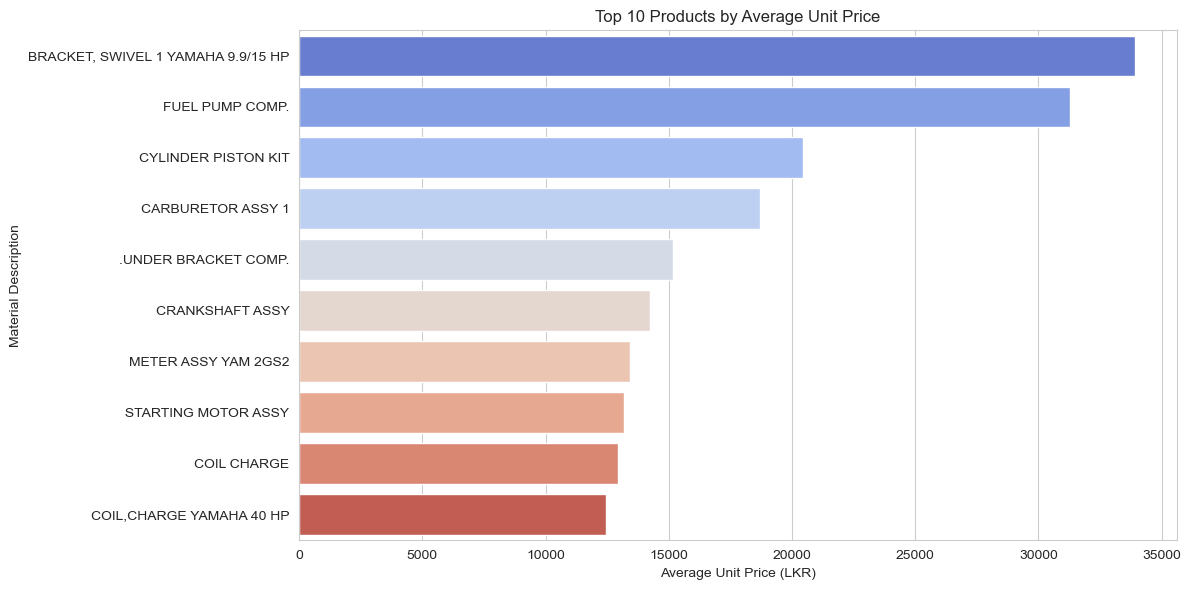

In [21]:
# Average unit price per product (top 10)
avg_price_per_product = df.groupby('Material Description')['Unit Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_per_product.values, y=avg_price_per_product.index, palette='coolwarm')
plt.title('Top 10 Products by Average Unit Price')
plt.xlabel('Average Unit Price (LKR)')
plt.tight_layout()
plt.show()

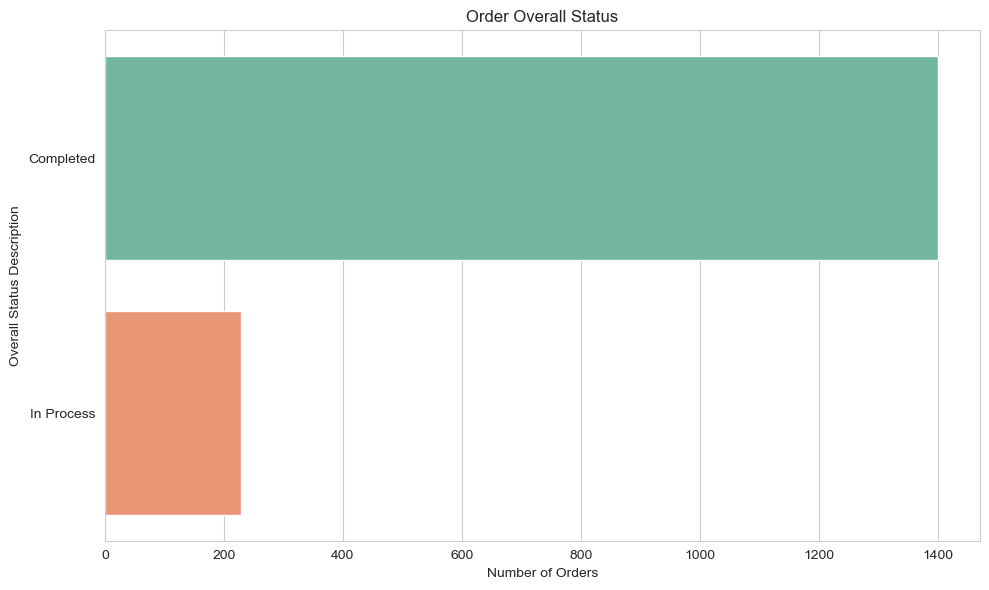

In [22]:
# Overall status counts
status_counts = df['Overall Status Description'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.values, y=status_counts.index, palette='Set2')
plt.title('Order Overall Status')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

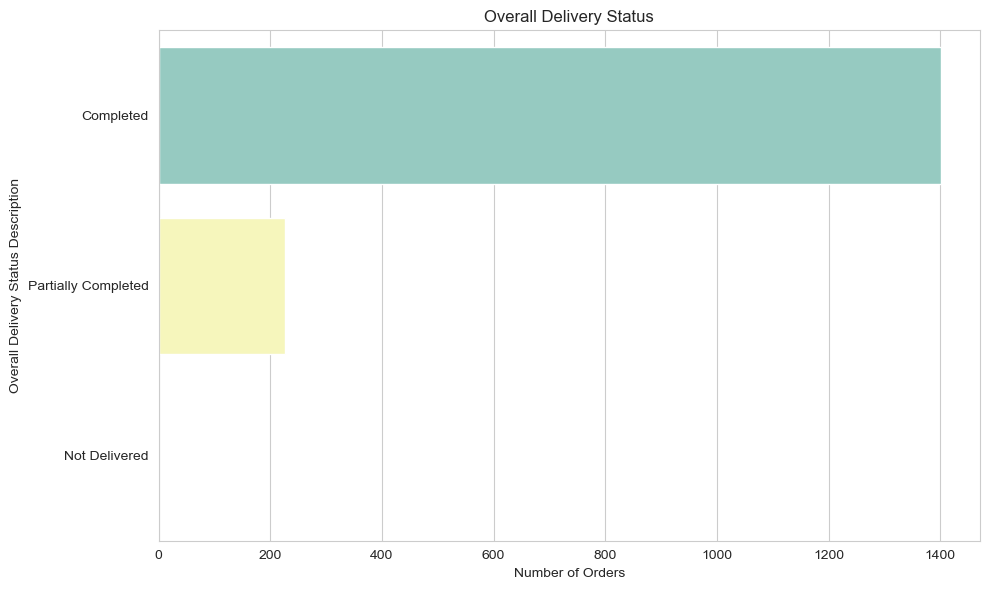

In [23]:
# Delivery status
delivery_status_counts = df['Overall Delivery Status Description'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=delivery_status_counts.values, y=delivery_status_counts.index, palette='Set3')
plt.title('Overall Delivery Status')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

In [24]:
cancelled = df[df['Overall Status Description'] == 'Order cancelled by customer']
print(f"Number of cancelled orders: {len(cancelled)}")
print(f"Total value of cancelled orders: {cancelled['Net Value (Item)'].sum():,.0f} LKR")
print(f"Percentage of total value cancelled: {cancelled['Net Value (Item)'].sum() / df['Net Value (Item)'].sum() * 100:.2f}%")

Number of cancelled orders: 0
Total value of cancelled orders: 0 LKR
Percentage of total value cancelled: 0.00%


In [25]:
cancelled['Rejection Reason Description'].value_counts(dropna=False)

Series([], Name: count, dtype: int64)

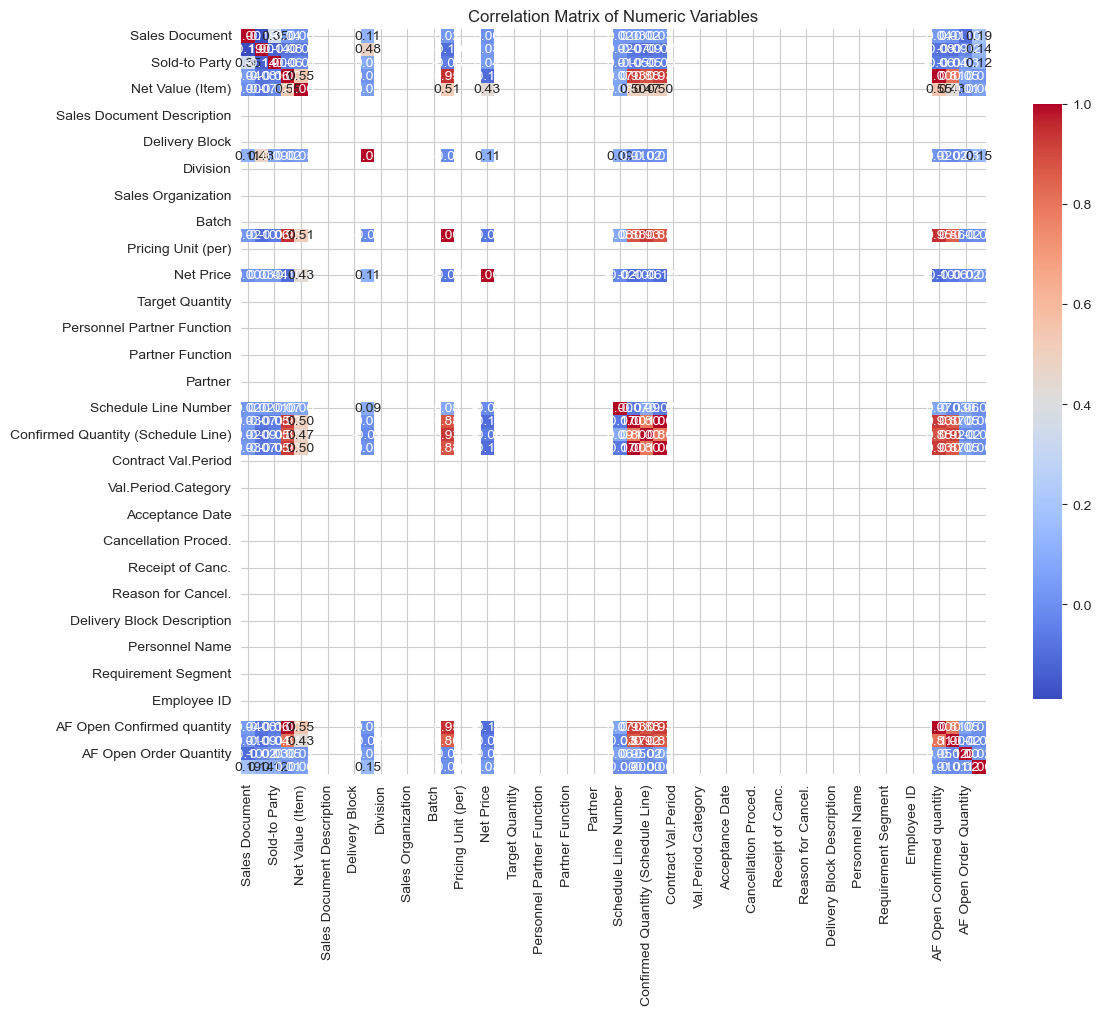

In [26]:
# Select numeric columns for correlation
num_df = df.select_dtypes(include=[np.number]).drop(columns=['Unit Price'])  # avoid duplicate info
plt.figure(figsize=(12, 10))
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

In [27]:
# Aggregate revenue per product
product_rev = df.groupby('Material Description')['Net Value (Item)'].sum().reset_index()
product_rev = product_rev.sort_values('Net Value (Item)', ascending=False).reset_index(drop=True)
product_rev['Cumulative Share'] = product_rev['Net Value (Item)'].cumsum() / product_rev['Net Value (Item)'].sum() * 100

In [28]:
def abc_class(share):
    if share <= 70:
        return 'A'
    elif share <= 90:
        return 'B'
    else:
        return 'C'

product_rev['ABC Class'] = product_rev['Cumulative Share'].apply(abc_class)

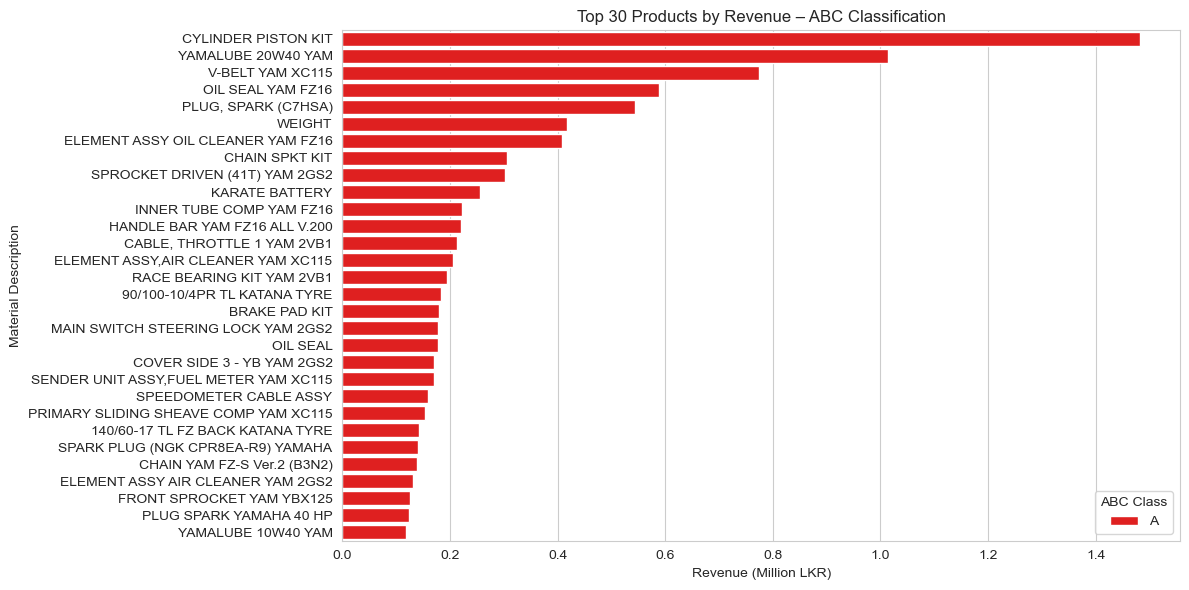

ABC class counts:
ABC Class
C    343
B    137
A     74
Name: count, dtype: int64


In [41]:
plt.figure(figsize=(12,6))
sns.barplot(data=product_rev.head(30), x=product_rev.head(30)['Net Value (Item)']/1e6, y='Material Description', hue='ABC Class', dodge=False, palette={'A':'red','B':'orange','C':'green'})
plt.title('Top 30 Products by Revenue – ABC Classification')
plt.xlabel('Revenue (Million LKR)')
plt.tight_layout()
plt.show()

print("ABC class counts:")
print(product_rev['ABC Class'].value_counts())

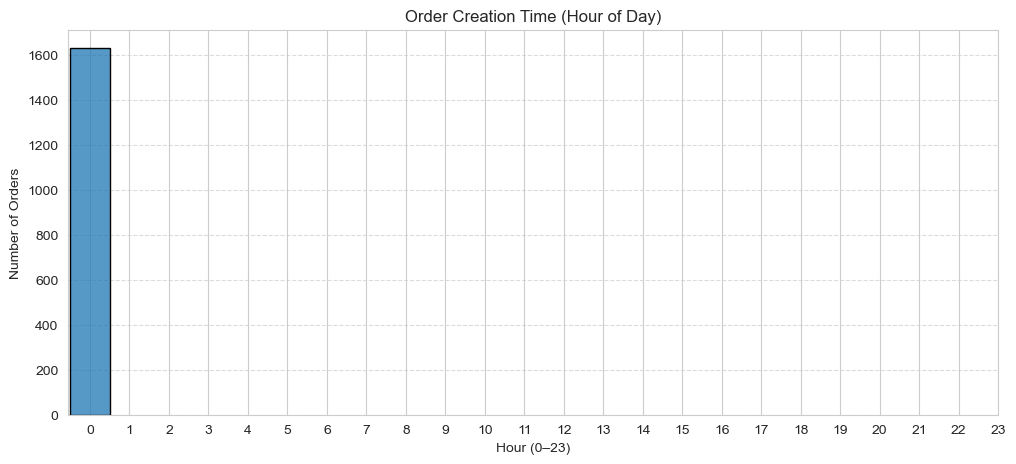

In [43]:
df['Created Hour'] = pd.to_datetime(df['Created On'], errors='coerce').dt.hour

plt.figure(figsize=(12, 5))
sns.histplot(df['Created Hour'].dropna(), bins=24, discrete=True, edgecolor='black')
plt.title('Order Creation Time (Hour of Day)')
plt.xlabel('Hour (0–23)')
plt.ylabel('Number of Orders')
plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [45]:
customer_stats = df.groupby('Sold-To Party Name').agg({
    'Sales Document': 'nunique',                # Number of orders
    'Net Value (Item)': 'sum',                  # Total spend
    'Order Quantity (Item)': 'sum'              # Total quantity
}).rename(columns={
    'Sales Document': 'OrderCount',
    'Net Value (Item)': 'TotalSpend',
    'Order Quantity (Item)': 'TotalQuantity'
})

In [46]:
customer_stats['AvgOrderValue'] = customer_stats['TotalSpend'] / customer_stats['OrderCount']

print("Top 10 customers by total spend:")
customer_stats.sort_values('TotalSpend', ascending=False).head(10)

Top 10 customers by total spend:


,OrderCount,TotalSpend,TotalQuantity,AvgOrderValue
Sold-To Party Name,,,,
Windom Motors,2,1719666.17,1322,859833.085
Wijesinghe Motors,1,1580059.33,1045,1580059.330
Wasantha Motors Galle,1,1299133.09,1081,1299133.090
Chandima Enterprises - Nikaweratiya,2,1121317.21,1985,560658.605
Ranga Motor (pvt) Ltd,1,955395.09,1246,955395.090
Kulunu Enterprises,1,684680.15,87,684680.150
Rashmika Auto Plaza,1,612902.44,442,612902.440
Anton Motors,1,537693.89,528,537693.890
Sunil Motorcycle Service,2,510454.53,448,255227.265


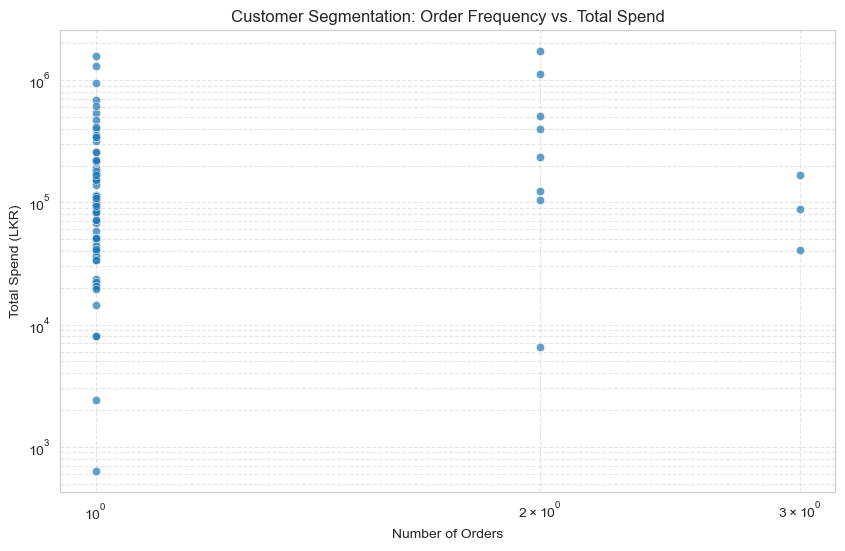

In [47]:
# Scatter plot: Order count vs. total spend
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_stats, x='OrderCount', y='TotalSpend', alpha=0.7)
plt.title('Customer Segmentation: Order Frequency vs. Total Spend')
plt.xlabel('Number of Orders')
plt.ylabel('Total Spend (LKR)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [48]:
product_stats = df.groupby('Material Description').agg({
    'Net Value (Item)': 'sum',
    'Order Quantity (Item)': 'sum'
}).rename(columns={'Net Value (Item)': 'Revenue', 'Order Quantity (Item)': 'Quantity'})


In [49]:
product_stats = product_stats.sort_values('Revenue', ascending=False)


In [50]:
# Calculate cumulative revenue share
product_stats['RevenueCum'] = product_stats['Revenue'].cumsum()
total_revenue = product_stats['Revenue'].sum()
product_stats['RevenueCumPct'] = product_stats['RevenueCum'] / total_revenue * 100


In [54]:
conditions = [
    product_stats['RevenueCumPct'] <= 70,
    (product_stats['RevenueCumPct'] > 70) & (product_stats['RevenueCumPct'] <= 90),
    product_stats['RevenueCumPct'] > 90
]
choices = ['A', 'B', 'C']
# add a string default so dtype matches the choices and avoid TypeError
product_stats['ABC_Class'] = np.select(conditions, choices, default='Other')

print("Number of products in each class:")
product_stats['ABC_Class'].value_counts()

Number of products in each class:


ABC_Class
C    343
B    137
A     74
Name: count, dtype: int64

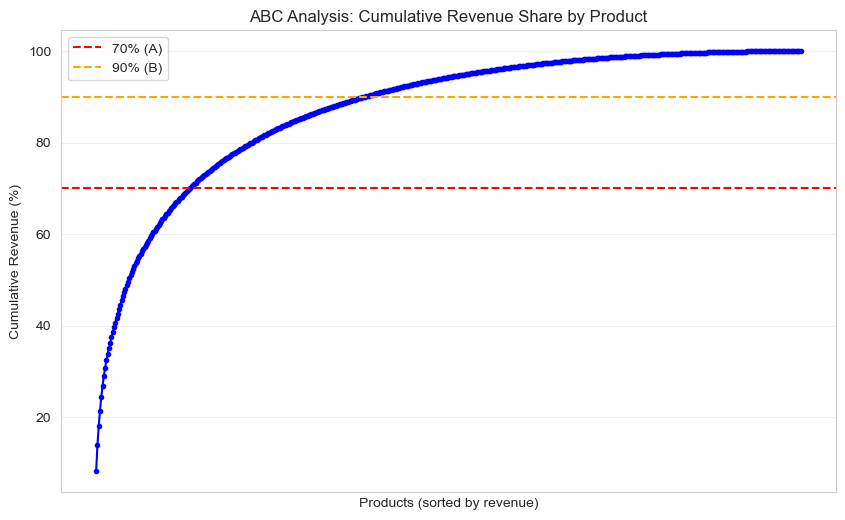

In [55]:
# Visualize the ABC curve
plt.figure(figsize=(10, 6))
plt.plot(product_stats.index, product_stats['RevenueCumPct'], marker='.', linestyle='-', color='blue')
plt.axhline(y=70, color='r', linestyle='--', label='70% (A)')
plt.axhline(y=90, color='orange', linestyle='--', label='90% (B)')
plt.title('ABC Analysis: Cumulative Revenue Share by Product')
plt.xlabel('Products (sorted by revenue)')
plt.ylabel('Cumulative Revenue (%)')
plt.xticks([])  # hide product names for clarity
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
# Goods Issue Date is when the item leaves warehouse, Delivery Date is promised arrival.
df['Delivery Delay'] = (df['Delivery Date'] - df['Goods Issue Date']).dt.days

# For orders where goods issue date is missing or delivery date missing, we cannot compute delay.
delay_data = df[df['Delivery Delay'].notna()].copy()

print("Delivery delay (days) summary:")
delay_data['Delivery Delay'].describe()

Delivery delay (days) summary:


count    1629.000000
mean       -3.154696
std         6.281139
min       -42.000000
25%        -6.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: Delivery Delay, dtype: float64

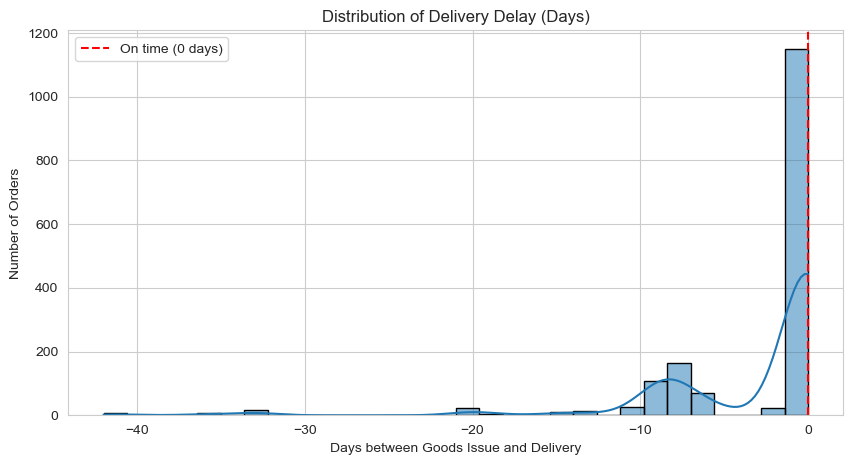

In [57]:
# Distribution of delivery delays
plt.figure(figsize=(10, 5))
sns.histplot(delay_data['Delivery Delay'], bins=30, kde=True, edgecolor='black')
plt.title('Distribution of Delivery Delay (Days)')
plt.xlabel('Days between Goods Issue and Delivery')
plt.ylabel('Number of Orders')
plt.axvline(x=0, color='red', linestyle='--', label='On time (0 days)')
plt.legend()
plt.show()

In [58]:
df['PromiseDelay'] = (df['Goods Issue Date'] - df['Material Availability Date']).dt.days

on_time = (df['PromiseDelay'] <= 0).sum()
total = df['PromiseDelay'].notna().sum()
print(f"On‑time delivery (goods issue on or before availability): {on_time}/{total} = {on_time/total*100:.1f}%")

On‑time delivery (goods issue on or before availability): 1629/1629 = 100.0%


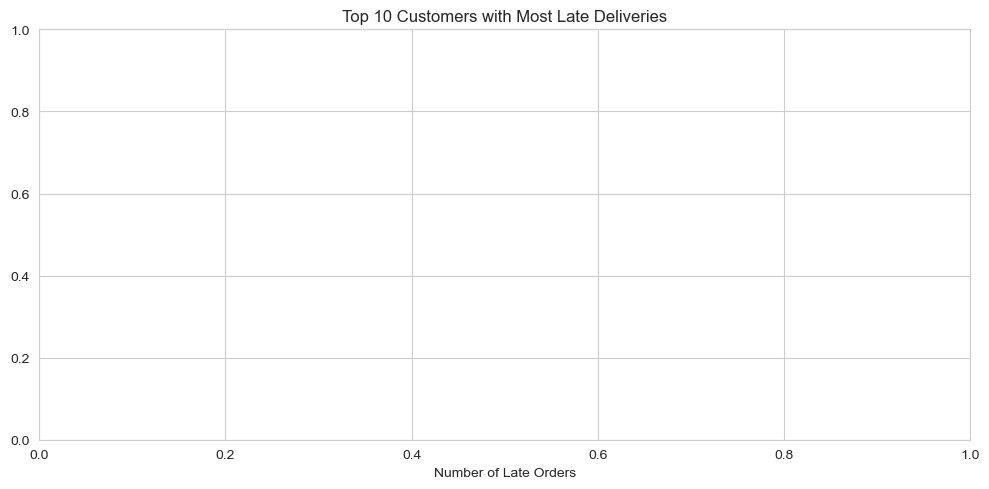

In [59]:
# Late deliveries by customer
late_orders = df[df['PromiseDelay'] > 0].groupby('Sold-To Party Name').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=late_orders.values, y=late_orders.index, palette='Reds_r')
plt.title('Top 10 Customers with Most Late Deliveries')
plt.xlabel('Number of Late Orders')
plt.tight_layout()
plt.show()

In [60]:
cancelled = df[df['Overall Status Description'] == 'Order cancelled by customer']
completed = df[df['Overall Status Description'] == 'Completed']

print(f"Cancelled orders: {len(cancelled)} ({len(cancelled)/len(df)*100:.1f}%)")
print(f"Completed orders: {len(completed)} ({len(completed)/len(df)*100:.1f}%)")

Cancelled orders: 0 (0.0%)
Completed orders: 1401 (86.0%)


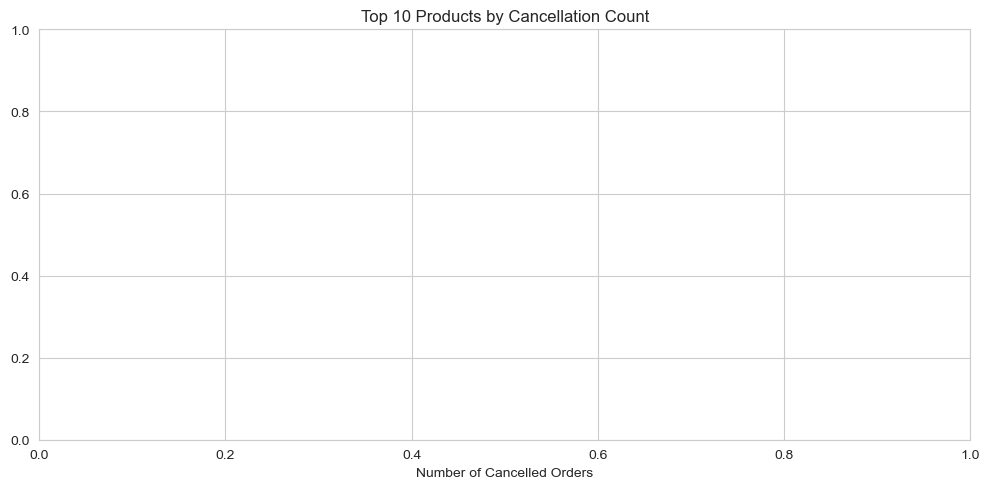

In [61]:
# Which products are cancelled most often?
top_cancelled_products = cancelled['Material Description'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cancelled_products.values, y=top_cancelled_products.index, palette='coolwarm')
plt.title('Top 10 Products by Cancellation Count')
plt.xlabel('Number of Cancelled Orders')
plt.tight_layout()
plt.show()

In [65]:
# Average unit price of cancelled vs completed
price_cancelled = cancelled['Unit Price'].dropna()
# calculate completed directly from df to avoid undefined variable
price_completed = df.loc[df['Overall Status Description'] != 'Order cancelled by customer', 'Unit Price'].dropna()

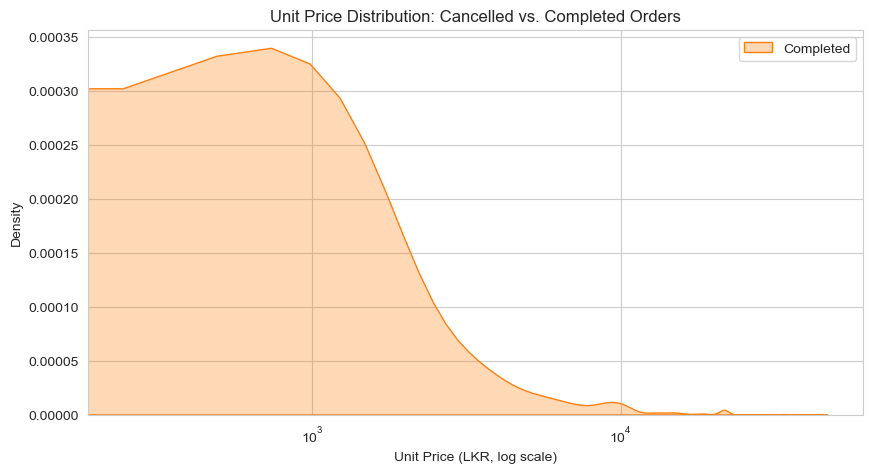

In [66]:
plt.figure(figsize=(10, 5))
sns.kdeplot(price_cancelled, label='Cancelled', fill=True, alpha=0.3)
sns.kdeplot(price_completed, label='Completed', fill=True, alpha=0.3)
plt.xscale('log')
plt.xlabel('Unit Price (LKR, log scale)')
plt.ylabel('Density')
plt.title('Unit Price Distribution: Cancelled vs. Completed Orders')
plt.legend()
plt.show()

In [69]:
from scipy import stats

# Statistical test
t_stat, p_value = stats.ttest_ind(price_cancelled, price_completed, equal_var=False)
print(f"T-test for unit price difference: t = {t_stat:.3f}, p = {p_value:.4f}")

T-test for unit price difference: t = nan, p = nan


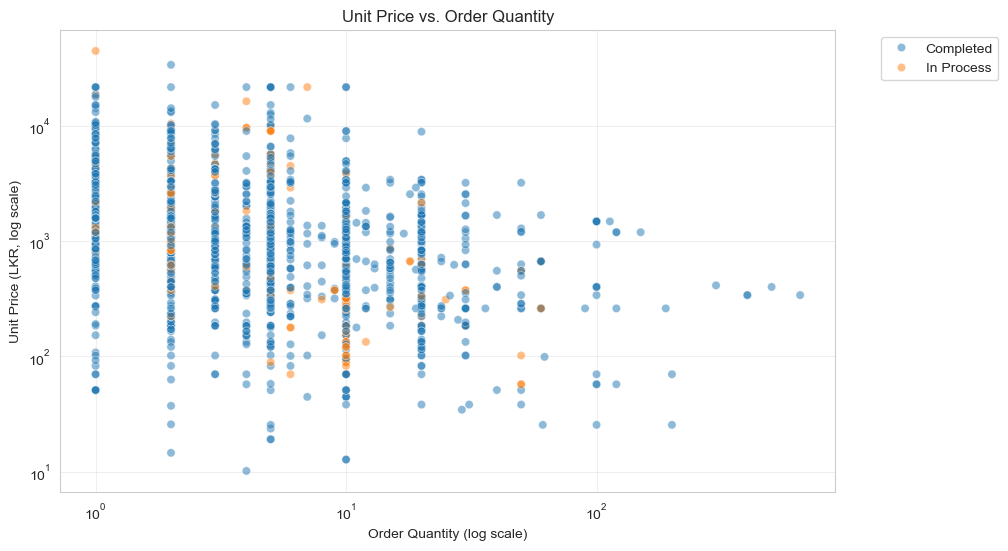

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Order Quantity (Item)', y='Unit Price', alpha=0.5, hue='Overall Status Description')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Order Quantity (log scale)')
plt.ylabel('Unit Price (LKR, log scale)')
plt.title('Unit Price vs. Order Quantity')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [71]:
# Compute correlation on log‑transformed values
log_qty = np.log(df['Order Quantity (Item)'].dropna())
log_price = np.log(df['Unit Price'].dropna())
corr, pval = stats.pearsonr(log_qty, log_price)
print(f"Pearson correlation (log quantity vs log price): {corr:.3f} (p = {pval:.4f})")

Pearson correlation (log quantity vs log price): -0.343 (p = 0.0000)


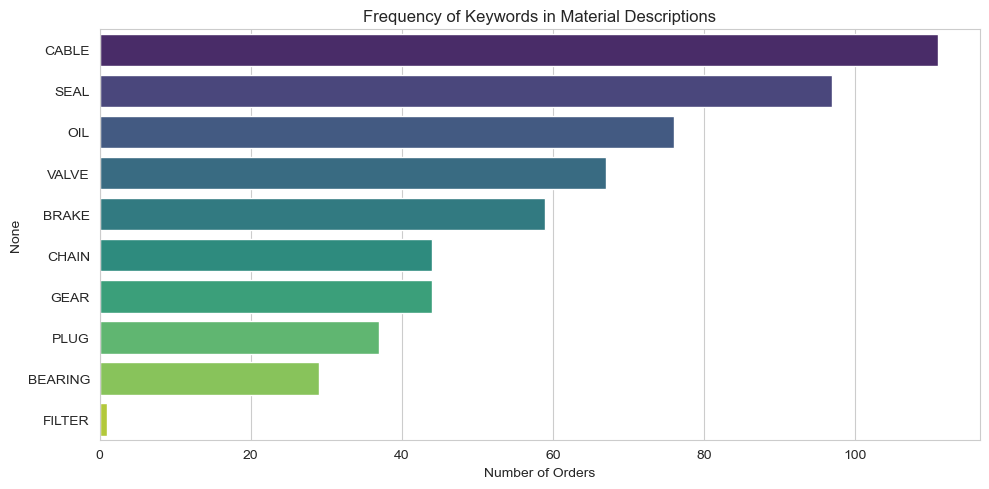

In [72]:
# Extract simple keywords from material descriptions (crude approach)
keywords = ['OIL', 'PLUG', 'SEAL', 'BEARING', 'FILTER', 'CABLE', 'BRAKE', 'CHAIN', 'GEAR', 'VALVE']
for kw in keywords:
    df[kw] = df['Material Description'].str.contains(kw, case=False, na=False).astype(int)

# Count orders containing each keyword
keyword_counts = df[keywords].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=keyword_counts.values, y=keyword_counts.index, palette='viridis')
plt.title('Frequency of Keywords in Material Descriptions')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

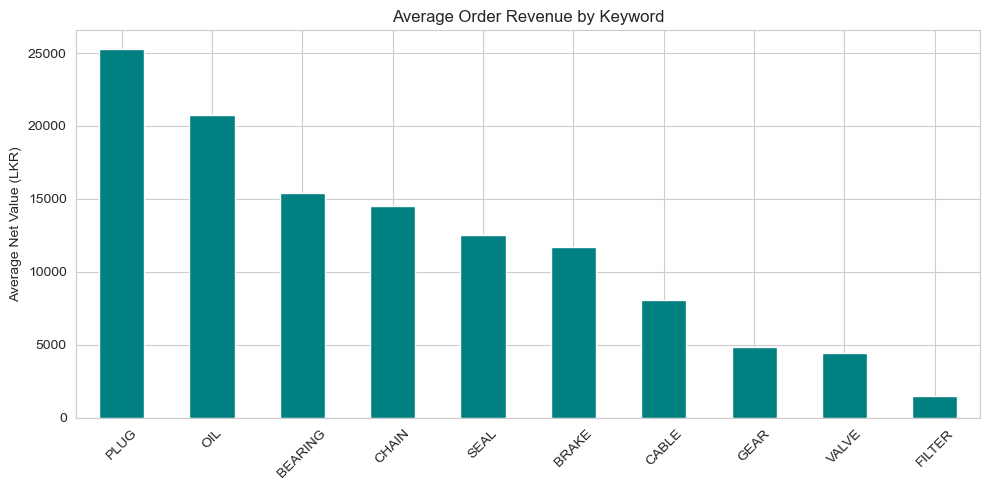

In [74]:
# Average revenue per order for orders containing specific keywords
revenue_per_keyword = {}
for kw in keywords:
    revenue_per_keyword[kw] = df[df[kw]==1]['Net Value (Item)'].mean()

pd.Series(revenue_per_keyword).sort_values(ascending=False).plot(kind='bar', figsize=(10,5), color='teal')
plt.title('Average Order Revenue by Keyword')
plt.ylabel('Average Net Value (LKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
def flag_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

df['Qty_Outlier'] = flag_outliers(df['Order Quantity (Item)'])
df['Value_Outlier'] = flag_outliers(df['Net Value (Item)'])

print(f"Quantity outliers: {df['Qty_Outlier'].sum()} rows ({df['Qty_Outlier'].sum()/len(df)*100:.1f}%)")
print(f"Value outliers: {df['Value_Outlier'].sum()} rows ({df['Value_Outlier'].sum()/len(df)*100:.1f}%)")

Quantity outliers: 109 rows (6.7%)
Value outliers: 134 rows (8.2%)


In [76]:
# Examine a few outliers
outliers = df[df['Value_Outlier']][['Material Description', 'Order Quantity (Item)', 'Net Value (Item)', 'Unit Price']]
outliers.head(10)

,Material Description,Order Quantity (Item),Net Value (Item),Unit Price
0,YAMALUBE 20W40 YAM,20,33686.40,1684.320000
1,YAMALUBE 20W40 YAM,20,33686.40,1684.320000
2,YAMALUBE 10W40 YAM,20,33686.40,1684.320000
3,"PLUG, SPARK (C7HSA)",650,220962.09,339.941677
12,COVER SIDE 3 - YB YAM 2GS2,5,28411.01,5682.202000
18,TANK SIDE COVER 1 YAM 2GS4,4,38593.23,9648.307500
19,GUIDE AIR 1 - YB YAM 2GS2,5,45413.14,9082.628000
22,FUEL PUMP COMP.,1,44752.12,44752.120000
32,WEIGHT,60,40042.35,667.372500
45,FENDER FRONT -CM6(cyan metal)XC115(B621),6,27000.00,4500.000000


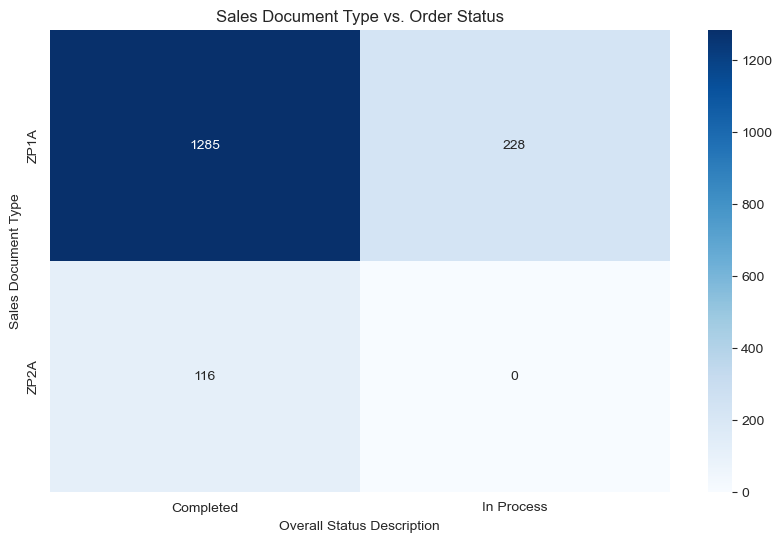

In [77]:
# Select a few categorical columns and create a cross‑tab heatmap
cat_cols_for_heatmap = ['Sales Document Type', 'Division', 'Overall Status Description', 'Overall Delivery Status Description']
# Create a cross‑tab of counts between two variables, e.g., Sales Document Type vs. Overall Status
ct = pd.crosstab(df['Sales Document Type'], df['Overall Status Description'])
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.title('Sales Document Type vs. Order Status')
plt.show()